In [ ]:
# TODO: add ortogonal init, does it change initial logits?
# TODO: calc dimensions
# TODO: bug, we can't generate more than seq len!
# TODO: vectorize forward pass, check if faster
# TODO: add layer support
# TODO: benchmark against pytorch RNN

CONFIG = {
    "block_size" : 64,
    "n_embed" : 128,
    "batch_size" : 64,
    "hidden_size" : 256,  # Increased from 10 to 256 for better capacity
    "n_epochs" : 50,      # Increased from 10 to 50    "batch_size" : 64,
    "learning_rate" : 3e-3,  # Increased from 1e-4 to 3e-3
}

In [2]:
import torch
DEVICE = torch.device("mps")

In [3]:
# load shakespear
with open("data/lotr.txt", "r", encoding="utf-8") as f: DATASET_TEXT = f.read()
DATASET_TEXT[:10000]

'In this reprint several minor inaccuracies, most of them noted by readers, have been corrected. For example, the text on pages 32 and 62 now corresponds exactly with the runes on Thror\'s Map. More important is the matter of Chapter Five. There the true story of the ending of the Riddle Game, as it was eventually revealed (under pressure) by Bilbo to Gandalf, is now given according to the Red Book, in place of the version Bilbo first gave to his friends, and actually set down in his diary. This departure from truth on the part of a most honest hobbit was a portent of great significance. It does not, however, concern the present story, and those who in this edition make their first acquaintance with hobbit-lore need not troupe about it. Its explanation lies in the history of the Ring, as it was set out in the chronicles of the Red Book of Westmarch, and is now told in The Lord of the Rings.\n\nA final note may be added, on a point raised by several students of the lore of the period. O

In [4]:
# create tokenizer
VOCAB = sorted(list(set(DATASET_TEXT)))
ctoi = dict([(c, i) for i, c in enumerate(VOCAB)])
itoc = dict([(i, c) for i, c in enumerate(VOCAB)])
encode = lambda str: [ctoi[c] for c in str]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
len(VOCAB), decode(encode("hello world"))

(108, 'hello world')

In [5]:
# tokenize shakespear
DATASET_TOKENS = encode(DATASET_TEXT)
len(DATASET_TOKENS), DATASET_TOKENS[:10]

(3301752, [36, 72, 1, 78, 66, 67, 77, 1, 76, 63])

In [6]:
import torch
from torch.utils.data import Dataset

class LOTRDataset(Dataset):
    def __init__(self, tokens, block_size=10):
        super().__init__()
        tokens = torch.tensor(tokens)
        chunk_size = block_size + 1
        n_chunks = len(tokens) // chunk_size
        chunks = tokens[:chunk_size * n_chunks]
        chunks = chunks.view(n_chunks, chunk_size)
        self.chunks = chunks
    
    def __getitem__(self, idx):
        tokens = self.chunks[idx]
        x = tokens[:-1]
        y = tokens[1:]
        return x, y
        
    def __len__(self):
        return len(self.chunks)

# Fixed: Pass block_size from CONFIG instead of using default 10
DATASET = LOTRDataset(DATASET_TOKENS, block_size=CONFIG["block_size"])
for i in range(10):
    x, y = DATASET[i]
    print(decode(x.tolist()))
    print(decode(y.tolist()))
    print("---")

In this reprint several minor inaccuracies, most of them noted b
n this reprint several minor inaccuracies, most of them noted by
---
 readers, have been corrected. For example, the text on pages 32
readers, have been corrected. For example, the text on pages 32 
---
and 62 now corresponds exactly with the runes on Thror's Map. Mo
nd 62 now corresponds exactly with the runes on Thror's Map. Mor
---
e important is the matter of Chapter Five. There the true story 
 important is the matter of Chapter Five. There the true story o
---
f the ending of the Riddle Game, as it was eventually revealed (
 the ending of the Riddle Game, as it was eventually revealed (u
---
nder pressure) by Bilbo to Gandalf, is now given according to th
der pressure) by Bilbo to Gandalf, is now given according to the
---
 Red Book, in place of the version Bilbo first gave to his frien
Red Book, in place of the version Bilbo first gave to his friend
---
s, and actually set down in his diary. This departure from tru

In [7]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    DATASET,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)
print(len(DATASET))
for x,y in dataloader:
    for i in range(x.shape[0]):
        print(decode(x[i].tolist()))
        print(decode(y[i].tolist()))
        print("----")
        break

50796
hed long lines of pillars, some of marble, some of copper and of
ed long lines of pillars, some of marble, some of copper and of 
----
n he lifted up his head and neighed. And out of the darkness the
 he lifted up his head and neighed. And out of the darkness the 
----
 start arid get it over.

Now Théoden spoke to Éomer, and he lif
start arid get it over.

Now Théoden spoke to Éomer, and he lift
----
 behind them walked Pippin with downcast head. But the servants 
behind them walked Pippin with downcast head. But the servants o
----
ui beyond the further Tower. Down from the hills on either side 
i beyond the further Tower. Down from the hills on either side o
----
ough the dusk.

The sky was clear and the stars were growing bri
ugh the dusk.

The sky was clear and the stars were growing brig
----
ster Stormcrow? _Láthspell_ I name you, Ill-news; and ill news i
ter Stormcrow? _Láthspell_ I name you, Ill-news; and ill news is
----
wildly. He opened his eyes, and heard a cock crow

In [8]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, vocab_size, hidden_size=CONFIG["hidden_size"], n_embed=CONFIG["n_embed"]):
        super().__init__()
        self.n_embed = n_embed
        self.hidden_size = hidden_size
        self.embeddings = nn.Embedding(vocab_size, n_embed)

        self.Wx = nn.Linear(n_embed, hidden_size, bias=True)
        self.Wh = nn.Linear(hidden_size, hidden_size, bias=True)
        
        self.ffn = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x_emb = self.embeddings(x)
        B, T, C = x_emb.shape

        outputs = []
        n_t = x_emb.shape[1]
        ht = torch.zeros((B, self.hidden_size)).to(DEVICE)
        for t in range(n_t):
            xt = x_emb[:, t, :]
            xt_hat = self.Wx(xt)
            ht_hat = self.Wh(ht)
            ht = torch.tanh(xt_hat + ht_hat)
            outputs.append(ht)
        outputs = torch.stack(outputs, dim=1)

        logits = self.ffn(outputs)
        return logits
        

VOCAB_SIZE = len(ctoi)
x, y = next(iter(dataloader))
x = x.to(DEVICE)
model = RNN(VOCAB_SIZE).to(DEVICE)
model(x)

tensor([[[-4.9170e-01,  9.8136e-02,  2.1510e-01,  ...,  5.0538e-01,
           7.5540e-02,  1.0465e-01],
         [-1.8303e-01, -4.3345e-01, -2.9417e-01,  ..., -5.8334e-01,
          -1.9364e-02, -6.8905e-01],
         [ 3.4720e-01, -1.3134e-01,  1.8646e-02,  ..., -2.5391e-01,
          -1.5790e-01, -1.6980e-02],
         ...,
         [-3.9821e-01, -6.2904e-02, -3.3186e-01,  ..., -2.9511e-01,
           1.1520e+00, -7.1775e-01],
         [-3.9753e-01, -6.1124e-01, -4.0536e-01,  ..., -1.7332e-01,
           3.2736e-01, -6.0835e-01],
         [-9.6529e-02, -3.1885e-01,  1.3534e-01,  ..., -1.0021e-01,
           5.6494e-02, -1.6901e-01]],

        [[ 4.4607e-01,  4.2291e-01,  2.9197e-01,  ...,  5.5981e-01,
          -5.0558e-02, -2.7484e-01],
         [ 2.0407e-01,  3.1389e-01,  4.8896e-02,  ...,  3.2136e-01,
           1.4006e-02,  2.4676e-01],
         [ 1.9601e-01, -8.4288e-02,  1.5060e-01,  ..., -2.0903e-01,
           8.9478e-02,  4.2116e-02],
         ...,
         [-1.4111e-01, -3

In [9]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

140396


In [10]:
total = 0
for name, param in model.named_parameters():
    total += param.numel()
    print(name, param.numel())
print(total)

embeddings.weight 13824
Wx.weight 32768
Wx.bias 256
Wh.weight 65536
Wh.bias 256
ffn.weight 27648
ffn.bias 108
140396


In [30]:
import torch.nn.functional as F

# TODO: must keep context window cropped to block size
# TODO: max len must take promtp into account
# TODO: this can be sped up
def generate(model, prompt, block_size=CONFIG["block_size"], max_len=None):
    print(prompt, end="")
    tokens = encode(prompt)

    if max_len is None: max_len = block_size - len(tokens)
    tokens = torch.tensor(tokens, device=DEVICE).unsqueeze(0)
    for _ in range(max_len):
        logits = model(tokens).squeeze(0)
        probs = F.softmax(logits, dim=-1)
        idxs = torch.multinomial(probs, num_samples=1)
        token = idxs[-1, :]
        token = token.item()
        print(decode([token]), end="")
        token_t = torch.tensor(token, device=DEVICE).unsqueeze(0).unsqueeze(0)
        tokens = torch.cat([tokens, token_t], dim=-1)
generate(model, "Frodo picked up")

Frodo picked up in necht as if be stood him. Rives; no, Merry me

In [12]:
model = RNN(VOCAB_SIZE)
model = model.to(DEVICE)
model

RNN(
  (embeddings): Embedding(108, 128)
  (Wx): Linear(in_features=128, out_features=256, bias=True)
  (Wh): Linear(in_features=256, out_features=256, bias=True)
  (ffn): Linear(in_features=256, out_features=108, bias=True)
)

In [19]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

lr = CONFIG["learning_rate"]
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
losses = []
gradnorms = []
leave = False
for epoch in range(CONFIG["n_epochs"]):
    bar = tqdm(dataloader) # TODO: reuse bar
    if leave: break
    for x, y in bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        #logits = F.softmax(logits, dim=-1)
        #y_pred = torch.multinomial(logits, dim=-1, num_samples=1)
        logits = logits.permute(0, 2, 1) # -> [N, C, L]      (64, 108, 10)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad()
        loss.backward()

        total_norm = clip_grad_norm_(model.parameters(), max_norm=float('inf'))
        gradnorms.append(total_norm.item())

        optimizer.step()
        loss_i = loss.item()
        bar.set_postfix(dict(epoch=epoch, loss=loss_i))
        losses.append(loss_i)
        #print(loss)


  4%|▍         | 35/794 [00:01<00:25, 29.81it/s, epoch=1, loss=1.37]


KeyboardInterrupt: 

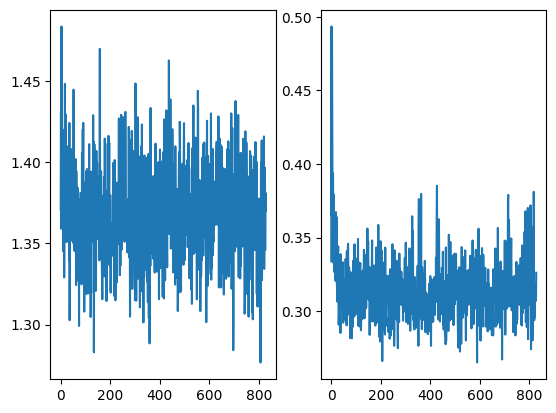

In [20]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 2)

ax[0].plot(losses)
ax[1].plot(gradnorms)


In [32]:
generate(model, "frodo", max_len=1024)

frodo.'
`Shelt.'
'Well, where their't yet node shape! The legs of silvictoments and north, that like ages over I wish to song. Indeed I beloved.

"Yes. He was beear had shrieged I know. Of Morgorb), and I knew us you. For sit like him near the thing, but no which after alf-letton went of hapsed among the time. Just east all waiting. 'Down at witherns that shadows could be for many evening in themselves and his own dack. "He was then are you gounded Frodo.
'When for Aragorn. "And many white. As if you can happened is thought you with new. Pry 17_! Someth up and cunning-foy, Pass down yourself out to the asterlight. I am not yet besonce of 'earnesed. In a shago mighty thy only the outlandil, as me apples, and them shairt. Frodo went a shields in with vanittle. ' said Gandalf.

The questient before the sile the watches promise, use-prying it, cliff the west was in the river when since he felt only Samximetimbs, and Éowyn rise!' said Boldûr. 'Alsneath it h

KeyboardInterrupt: 